In [2]:
import pandas as pd

df = pd.read_csv('../resources/stack-overflow-developer-survey-2025/survey_results_public.csv')

/var/folders/pm/cr2jym353f5bckqff3dz1l800000gn/T/ipykernel_40484/2466482609.py:3: DtypeWarning: Columns (0: JobSatPoints_15_TEXT, 1: DatabaseHaveEntry, 2: DevEnvHaveEntry, 3: SOTagsHaveEntry, 4: SOTagsWant Entry, 5: OfficeStackWantEntry, 6: CommPlatformHaveEntr, 7: CommPlatformWantEntr, 8: SO_Actions_15_TEXT, 9: AIAgentOrchestration, 10: AIAgentObsWrite) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../resources/stack-overflow-developer-survey-2025/survey_results_public.csv')


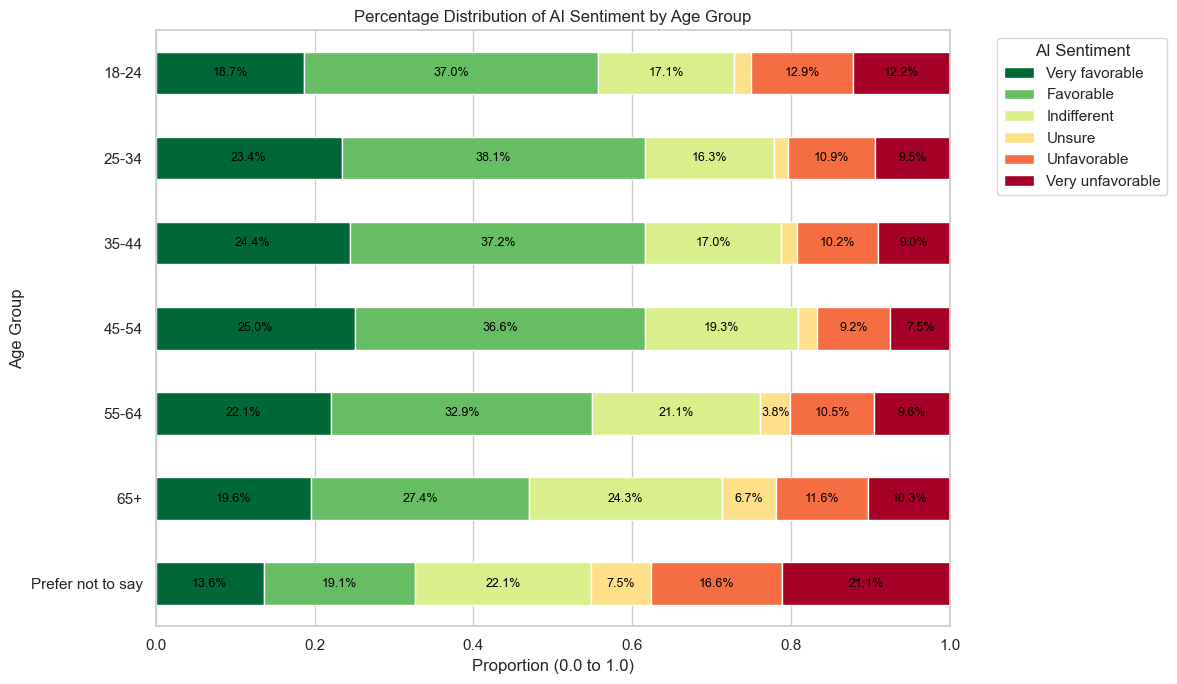

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Setup and Clean Data
aimodels = df[['AISent', 'Age']].copy()
aimodels = aimodels.dropna()

# --- NEW: Map exact dataset strings to clean labels ---
# This dictionary looks for the exact string on the left, and replaces it with the clean text on the right
age_mapping = {
    '18-24 years old': '18-24',
    '25-34 years old': '25-34',
    '35-44 years old': '35-44',
    '45-54 years old': '45-54',
    '55-64 years old': '55-64',
    '65 years or older': '65+',
    'Prefer not to say': 'Prefer not to say'
}

# Apply the mapping to create the new AgeGroup column
aimodels['AgeGroup'] = aimodels['Age'].map(age_mapping)

# Define the correct chronological order for the Y-axis
expected_age_order = [
    '18-24', '25-34', '35-44', '45-54', 
    '55-64', '65+', 'Prefer not to say'
]
aimodels['AgeGroup'] = pd.Categorical(aimodels['AgeGroup'], categories=expected_age_order, ordered=True)
# ----------------------------------------------------

# Define exact order for AISent
expected_sent_order = [
    "Very favorable", "Favorable", "Indifferent", 
    "Unsure", "Unfavorable", "Very unfavorable"
]
aimodels['AISent'] = pd.Categorical(aimodels['AISent'], categories=expected_sent_order, ordered=True)

# 2. Create the normalized crosstab
crosstab_percent = pd.crosstab(aimodels['AgeGroup'], aimodels['AISent'], normalize='index')

# 3. Apply Seaborn styling
sns.set_theme(style="whitegrid")

# 4. Plot the 100% stacked HORIZONTAL bar chart
plt.figure(figsize=(12, 7))
ax = crosstab_percent.plot(kind='barh', stacked=True, colormap='RdYlGn_r', ax=plt.gca())

# 5. Add Percentage Labels inside the bars
for p in ax.patches:
    height = p.get_height()
    width = p.get_width()
    x, y = p.get_xy()
    
    # Only show text if the bar segment is larger than 3%
    if width > 0.03:
        center_x = x + width / 2
        center_y = y + height / 2
        
        ax.text(center_x, center_y, f'{width * 100:.1f}%', 
                ha='center', va='center', color='black', fontsize=9)

# 6. Formatting the chart
plt.title('Percentage Distribution of AI Sentiment by Age Group')
plt.xlabel('Proportion (0.0 to 1.0)')
plt.ylabel('Age Group')

plt.xlim(0, 1)
ax.invert_yaxis() # Youngest at the top, down to 'Prefer not to say' at the bottom

# Move legend outside
plt.legend(title='AI Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()

# Display the plot
plt.show()

In [19]:
# Returns an array of all unique age values
unique_ages = df['Age'].unique()
print(unique_ages)

<StringArray>
[  '25-34 years old',   '35-44 years old',   '45-54 years old',
   '18-24 years old', '65 years or older',   '55-64 years old',
 'Prefer not to say']
Length: 7, dtype: str


In [31]:
import pandas as pd


def process_ai_sentiment_by_age(df, col, mapping_col, age_mapping, expected_order, ai_sent_col='AISent'):
    # 1. Setup and Clean Data
    aimodels = df[[ai_sent_col, col]].copy()
    aimodels = aimodels.dropna()

    age_mapping = {
        '18-24 years old': '18-24',
        '25-34 years old': '25-34',
        '35-44 years old': '35-44',
        '45-54 years old': '45-54',
        '55-64 years old': '55-64',
        '65 years or older': '65+',
        'Prefer not to say': 'Prefer not to say'
    }
    aimodels[mapping_col] = aimodels[col].map(age_mapping)

    aimodels[mapping_col] = pd.Categorical(aimodels[mapping_col], categories=expected_order, ordered=True)

    expected_sent_order = ["Very favorable", "Favorable", "Indifferent", "Unsure", "Unfavorable", "Very Unfavorable"]
    aimodels[ai_sent_col] = pd.Categorical(aimodels[ai_sent_col], categories=expected_sent_order, ordered=True)

    # 2. Create the base dataframe of proportions (0.0 to 1.0)
    df_proportions = pd.crosstab(aimodels[mapping_col], aimodels[ai_sent_col], normalize='index')

    # 3. Convert to percentages and round to 2 decimal places
    df_percentages = (df_proportions * 100).round(2)

    # 4. Clean up the dataframe structure
    # Reset index makes 'AgeGroup' a normal column instead of the dataframe's index
    df_percentages = df_percentages.reset_index()

    # Remove the leftover 'AISent' label from the columns axis for a cleaner table
    df_percentages.columns.name = None 

    return df_percentages

# get all unique values in a column
def get_unique_values(df, col):
    unique_values = df[col].unique()
    return unique_values

In [29]:
age_mapping = {
    '18-24 years old': '18-24',
    '25-34 years old': '25-34',
    '35-44 years old': '35-44',
    '45-54 years old': '45-54',
    '55-64 years old': '55-64',
    '65 years or older': '65+',
    'Prefer not to say': 'Prefer not to say'
}

expected_age_order = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+', 'Prefer not to say']

newdf = process_ai_sentiment_by_age(df, col='Age', mapping_col='AgeGroup', age_mapping=age_mapping, expected_order=expected_age_order)
print(newdf)

            AgeGroup  Very favorable  Favorable  Indifferent  Unsure  \
0              18-24           21.31      42.12        19.48    2.38   
1              25-34           25.88      42.13        18.01    1.94   
2              35-44           26.87      40.91        18.71    2.29   
3              45-54           27.07      39.53        20.85    2.57   
4              55-64           24.42      36.41        23.35    4.25   
5                65+           21.83      30.53        27.14    7.52   
6  Prefer not to say           17.20      24.20        28.03    9.55   

   Unfavorable  
0        14.71  
1        12.03  
2        11.22  
3         9.97  
4        11.57  
5        12.98  
6        21.02  


/var/folders/pm/cr2jym353f5bckqff3dz1l800000gn/T/ipykernel_40484/3119593655.py:23: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  aimodels[ai_sent_col] = pd.Categorical(aimodels[ai_sent_col], categories=expected_sent_order, ordered=True)


In [ ]:
education_mapping = {
    'Bachelor’s degree': 'Bachelor',
    'Master’s degree (M.A., M.S., M.Eng., MBA, etc.)': 'Master',
    'Doctoral degree': 'Doctoral',
    'High school diploma or equivalent': 'High School',
    'Some college or associate degree': 'Some College',
    'No formal education': 'No Education'

}

expected_age_order = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+', 'Prefer not to say']

newdf = process_ai_sentiment_by_age(df, col='Age', mapping_col='AgeGroup', age_mapping=age_mapping, expected_order=expected_age_order)
print(newdf)

In [ ]:


print(get_unique_values(df, 'EdLevel'))

<StringArray>
[                                   'Master’s degree (M.A., M.S., M.Eng., MBA, etc.)',
                                                'Associate degree (A.A., A.S., etc.)',
                                       'Bachelor’s degree (B.A., B.S., B.Eng., etc.)',
                             'Some college/university study without earning a degree',
                                     'Professional degree (JD, MD, Ph.D, Ed.D, etc.)',
 'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)',
                                                            'Other (please specify):',
                                                          'Primary/elementary school',
                                                                                  nan]
Length: 9, dtype: str
